# Tableau de synthèse des combos — `blob_nn_4x10-1`

Ce notebook parcourt les dossiers de résultats (un par combo de bound strategy),
et pour chacun combine deux sources :

- **`results.csv`** → taux de certification (`optimal_value > 0`)
- **`stable_actives_study.csv`** → bornes **LB**/**UB** des deux neurones impliqués
  dans le produit croisé du combo, identifiés dans le nom du dossier via `l{L}_u{U}_k{K}_j{J}`
  (neurone 1 : couche `L`, indice `U` ; neurone 2 : couche `K`, indice `J`).

**Règles retenues** :
- Une ligne de `results.csv` est **certifiée** si `optimal_value > 0`.
- Les bornes LB/UB sont **moyennées** sur toutes les lignes (tous les `data_index`) de
  `stable_actives_study.csv`.
- Le combo `combo_0000` (baseline, `all_one_variable`) n'a pas de paire de neurones
  spécifique → les colonnes LB/UB restent vides (`NaN`) pour cette ligne, et son nom
  de stratégie est fixé à `none`.


In [1]:
import re
from pathlib import Path

import pandas as pd

# === CONFIGURATION ===

# Racine contenant tous les dossiers de runs (un par combo).
# Adaptez ce chemin à votre arborescence WSL, ex:
# BENCHMARK_ROOT = Path("/mnt/c/Users/vous/.../results/benchmark/blob_nn_4x10-1")
BENCHMARK_ROOT = Path("../results/benchmark/blob_nn_4x10-1")

# Nom du dossier de run, ex:
#   2026_07_08_15h28_19s_test__combo_0000__baseline__all_one_variable
#   2026_07_09_01h54_43s_test__combo_0001__product_0__l0_u0_k1_j0__composed
RUN_DIR_RE = re.compile(r"combo_(\d+)__(.+)$")
PRODUCT_IDX_RE = re.compile(r"l(\d+)_u(\d+)_k(\d+)_j(\d+)")

# Nombre de runs (data_index) attendu par combo:
# - results.csv avec plus de MAX_RUNS lignes -> tronqué aux MAX_RUNS premières
# - results.csv avec moins de MIN_RUNS lignes -> le combo est écarté du tableau
MIN_RUNS = 78
MAX_RUNS = 78


In [9]:
def parse_run_dir(dirname: str) -> dict:
    """Extrait combo_id, stratégie, et les indices (l,u,k,j) si présents."""
    m = RUN_DIR_RE.search(dirname)
    if not m:
        return None

    combo_id = int(m.group(1))
    rest = m.group(2)  # ex: "product_0__l0_u0_k1_j0__composed" ou "baseline__all_one_variable"

    idx_match = PRODUCT_IDX_RE.search(rest)
    if idx_match:
        l, u, k, j = map(int, idx_match.groups())
        strategy = rest.rsplit("__", 1)[-1]  # dernier segment = nom de la stratégie
    else:
        l = u = k = j = None
        strategy = "none" if combo_id == 0 else rest

    return {
        "combo": f"combo_{combo_id:04d}",
        "combo_id": combo_id,
        "strategy": strategy,
        "l": l, "u_idx": u, "k": k, "j_idx": j,
    }


def find_run_dirs(root: Path) -> list[dict]:
    """Retourne la liste des runs trouvés avec leurs métadonnées et chemins de fichiers."""
    if not root.exists():
        raise FileNotFoundError(f"Dossier introuvable: {root.resolve()}")

    runs = []
    for d in sorted(root.glob("*__combo_*")):
        if not d.is_dir():
            continue
        meta = parse_run_dir(d.name)
        if meta is None:
            print(f"[!] Nom de dossier non reconnu, ignoré: {d.name}")
            continue

        results_csv = d / "results.csv"
        stable_csv = d / "stable_actives_study.csv"

        if not results_csv.exists():
            print(f"[!] Pas de results.csv dans {d.name}")
            continue
        if not stable_csv.exists():
            print(f"[!] Pas de stable_actives_study.csv dans {d.name}")

        meta["results_csv"] = results_csv
        meta["stable_csv"] = stable_csv if stable_csv.exists() else None
        meta["dirname"] = d.name
        runs.append(meta)

    return sorted(runs, key=lambda r: r["combo_id"])


runs = find_run_dirs(BENCHMARK_ROOT)
print(f"{len(runs)} run(s) trouvé(s):")
for r in runs:
    print(f"  {r['combo']} ({r['strategy']}) l={r['l']} u={r['u_idx']} k={r['k']} j={r['j_idx']}")


[!] Pas de results.csv dans 2026_07_10_13h31_53s_test__combo_0000__baseline__all_one_variable
[!] Pas de results.csv dans your_run_title__combo_0163__product_162__l2_u1_k4_j0__composed
[!] Pas de results.csv dans your_run_title__combo_0247__product_246__l3_u1_k4_j0__composed
138 run(s) trouvé(s):
  combo_0000 (none) l=None u=None k=None j=None
  combo_0000 (none) l=None u=None k=None j=None
  combo_0000 (none) l=None u=None k=None j=None
  combo_0000 (none) l=None u=None k=None j=None
  combo_0000 (none) l=None u=None k=None j=None
  combo_0000 (none) l=None u=None k=None j=None
  combo_0001 (composed) l=0 u=0 k=1 j=0
  combo_0001 (composed) l=0 u=0 k=1 j=0
  combo_0002 (composed) l=0 u=0 k=1 j=1
  combo_0002 (composed) l=0 u=0 k=1 j=1
  combo_0002 (composed) l=0 u=0 k=1 j=1
  combo_0003 (composed) l=0 u=0 k=1 j=2
  combo_0003 (composed) l=0 u=0 k=1 j=2
  combo_0004 (composed) l=0 u=0 k=2 j=0
  combo_0004 (composed) l=0 u=0 k=2 j=0
  combo_0005 (composed) l=0 u=0 k=2 j=1
  combo_0006 (

In [10]:
def load_limited_csv(csv_path: Path, min_rows: int = MIN_RUNS, max_rows: int = MAX_RUNS) -> pd.DataFrame | None:
    """Charge un CSV, le tronque à max_rows lignes, ou renvoie None s'il en a moins que min_rows."""
    df = pd.read_csv(csv_path)
    n_original = len(df)
    if n_original < min_rows:
        return None
    if n_original > max_rows:
        df = df.iloc[:max_rows].reset_index(drop=True)
    assert len(df) <= max_rows, (
        f"BUG: {csv_path} a {len(df)} lignes après troncature (attendu <= {max_rows})"
    )
    return df


def certification_rate(results_df: pd.DataFrame) -> tuple[float, int, float]:
    certified = results_df["optimal_value"] > 0
    return certified.mean(), len(results_df), results_df["optimal_value"].mean()


def neuron_bounds(stable_df: pd.DataFrame | None, layer: int | None, neuron: int | None) -> tuple[float, float]:
    """Moyenne de LB/UB pour Layer_{layer}_Neuron_{neuron} sur toutes les lignes (déjà limitées)."""
    if stable_df is None or layer is None or neuron is None:
        return float("nan"), float("nan")

    lb_col = f"LB_Layer_{layer}_Neuron_{neuron}"
    ub_col = f"UB_Layer_{layer}_Neuron_{neuron}"

    if lb_col not in stable_df.columns or ub_col not in stable_df.columns:
        print(f"[!] Colonnes {lb_col}/{ub_col} absentes")
        return float("nan"), float("nan")

    return stable_df[lb_col].mean(), stable_df[ub_col].mean()


In [14]:
rows = []
skipped = []
for r in runs:

    results_df = load_limited_csv(r["results_csv"])
    if results_df is None:
        skipped.append(r["combo"])
        continue

    cert_rate, n_runs, optimal_value_avg = certification_rate(results_df)

    stable_df = load_limited_csv(r["stable_csv"]) if r["stable_csv"] is not None else None
    lb1, ub1 = neuron_bounds(stable_df, r["l"], r["u_idx"])
    lb2, ub2 = neuron_bounds(stable_df, r["k"], r["j_idx"])

    rows.append({
        "combo": r["combo"],
        "strategy": r["strategy"],
        "l": r["l"], "u_idx": r["u_idx"], "k": r["k"], "j_idx": r["j_idx"],
        "n_runs": n_runs,
        "certification_rate": cert_rate,
        "optimal_value_avg": optimal_value_avg,
        "LB_neuron1": lb1, "UB_neuron1": ub1,
        "LB_neuron2": lb2, "UB_neuron2": ub2,
    })

summary_df = pd.DataFrame(rows)

if skipped:
    print(f"{len(skipped)} combo(s) écarté(s) (moins de {MIN_RUNS} runs): {skipped}")

# Vérification explicite : aucun n_runs ne doit dépasser MAX_RUNS.
# Si ça arrive, on affiche le vrai nombre de lignes du results.csv d'origine
# pour comprendre d'où vient l'écart (ex: notebook pas ré-exécuté après édition,
# combo dupliqué dans plusieurs dossiers, etc.)
bad = summary_df[summary_df["n_runs"] > MAX_RUNS]
if not bad.empty:
    print("[BUG] Combos dépassant MAX_RUNS malgré la troncature :")
    for combo in bad["combo"]:
        r = next(x for x in runs if x["combo"] == combo)
        raw_len = len(pd.read_csv(r["results_csv"]))
        print(f"  {combo}: n_runs={raw_len} lignes brutes dans {r['results_csv']}")
    raise AssertionError(
        "Des combos dépassent MAX_RUNS après troncature — voir détails ci-dessus. "
        "Vérifiez que vous exécutez bien la dernière version du notebook."
    )

summary_df


5 combo(s) écarté(s) (moins de 78 runs): ['combo_0000', 'combo_0000', 'combo_0000', 'combo_0172', 'combo_0324']


,combo,strategy,l,u_idx,k,j_idx,n_runs,certification_rate,optimal_value_avg,LB_neuron1,UB_neuron1,LB_neuron2,UB_neuron2
0,combo_0000,none,NaN,NaN,NaN,NaN,78,0.525641,-2.731249,NaN,NaN,NaN,NaN
1,combo_0000,none,NaN,NaN,NaN,NaN,78,0.500000,-3.183769,NaN,NaN,NaN,NaN
2,combo_0000,none,NaN,NaN,NaN,NaN,78,0.500000,-3.177863,NaN,NaN,NaN,NaN
3,combo_0001,composed,0.0,0.0,1.0,0.0,78,0.500000,-3.186794,1.908244,2.908244,2.060857,3.128471
4,combo_0001,composed,0.0,0.0,1.0,0.0,78,0.500000,-3.189048,1.908244,2.908244,2.060857,3.128471
...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,combo_0313,composed,4.0,4.0,5.0,0.0,78,0.500000,-3.174854,1.015100,18.204956,-2.369864,41.711026
129,combo_0321,composed,4.0,6.0,5.0,2.0,78,0.500000,-3.186604,-3.404153,0.234527,-6.966573,50.099772
130,combo_0323,composed,4.0,7.0,5.0,1.0,78,0.487179,-3.183515,-0.590869,8.553629,-4.214189,18.790716
131,combo_0329,composed,4.0,9.0,5.0,1.0,78,0.500000,-3.180917,-2.349908,-0.636523,-4.214189,18.790716


## Tableau formaté pour lecture / rapport

In [15]:
display_df = summary_df.copy()
display_df["certification_rate"] = (display_df["certification_rate"] * 100).round(1).astype(str) + " %"
for col in ["optimal_value_avg", "LB_neuron1", "UB_neuron1", "LB_neuron2", "UB_neuron2"]:
    display_df[col] = display_df[col].round(4)

display_df


,combo,strategy,l,u_idx,k,j_idx,n_runs,certification_rate,optimal_value_avg,LB_neuron1,UB_neuron1,LB_neuron2,UB_neuron2
0,combo_0000,none,NaN,NaN,NaN,NaN,78,52.6 %,-2.7312,NaN,NaN,NaN,NaN
1,combo_0000,none,NaN,NaN,NaN,NaN,78,50.0 %,-3.1838,NaN,NaN,NaN,NaN
2,combo_0000,none,NaN,NaN,NaN,NaN,78,50.0 %,-3.1779,NaN,NaN,NaN,NaN
3,combo_0001,composed,0.0,0.0,1.0,0.0,78,50.0 %,-3.1868,1.9082,2.9082,2.0609,3.1285
4,combo_0001,composed,0.0,0.0,1.0,0.0,78,50.0 %,-3.1890,1.9082,2.9082,2.0609,3.1285
...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,combo_0313,composed,4.0,4.0,5.0,0.0,78,50.0 %,-3.1749,1.0151,18.2050,-2.3699,41.7110
129,combo_0321,composed,4.0,6.0,5.0,2.0,78,50.0 %,-3.1866,-3.4042,0.2345,-6.9666,50.0998
130,combo_0323,composed,4.0,7.0,5.0,1.0,78,48.7 %,-3.1835,-0.5909,8.5536,-4.2142,18.7907
131,combo_0329,composed,4.0,9.0,5.0,1.0,78,50.0 %,-3.1809,-2.3499,-0.6365,-4.2142,18.7907


In [ ]:
display_df.head(20)

,combo,strategy,l,u_idx,k,j_idx,n_runs,certification_rate,optimal_value_avg,LB_neuron1,UB_neuron1,LB_neuron2,UB_neuron2
0,combo_0000,none,NaN,NaN,NaN,NaN,78,52.6 %,-2.7312,NaN,NaN,NaN,NaN
1,combo_0000,none,NaN,NaN,NaN,NaN,78,50.0 %,-3.1838,NaN,NaN,NaN,NaN
2,combo_0000,none,NaN,NaN,NaN,NaN,78,50.0 %,-3.1779,NaN,NaN,NaN,NaN
3,combo_0001,composed,0.0,0.0,1.0,0.0,78,50.0 %,-3.1868,1.9082,2.9082,2.0609,3.1285
4,combo_0001,composed,0.0,0.0,1.0,0.0,78,50.0 %,-3.1890,1.9082,2.9082,2.0609,3.1285
5,combo_0002,composed,0.0,0.0,1.0,1.0,78,50.0 %,-3.1784,1.9082,2.9082,-0.6262,-0.3854
6,combo_0002,composed,0.0,0.0,1.0,1.0,78,50.0 %,-3.1923,1.9082,2.9082,-0.6262,-0.3854
7,combo_0002,composed,0.0,0.0,1.0,1.0,78,50.0 %,-3.1958,1.9082,2.9082,-0.6262,-0.3854
8,combo_0003,composed,0.0,0.0,1.0,2.0,78,52.6 %,-2.7306,1.9082,2.9082,-0.6534,-0.1954
9,combo_0003,composed,0.0,0.0,1.0,2.0,78,50.0 %,-3.1877,1.9082,2.9082,-0.6534,-0.1954


: 

## Visualisation des résultats

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# On s'assure que les plots s'affichent bien dans le notebook
%matplotlib inline

# Style des plots
plt.style.use('seaborn-v0_8-whitegrid')
print("Matplotlib et Seaborn importés pour la visualisation.")

Matplotlib et Seaborn importés pour la visualisation.


--- Impact des bornes du neurone 1 ---


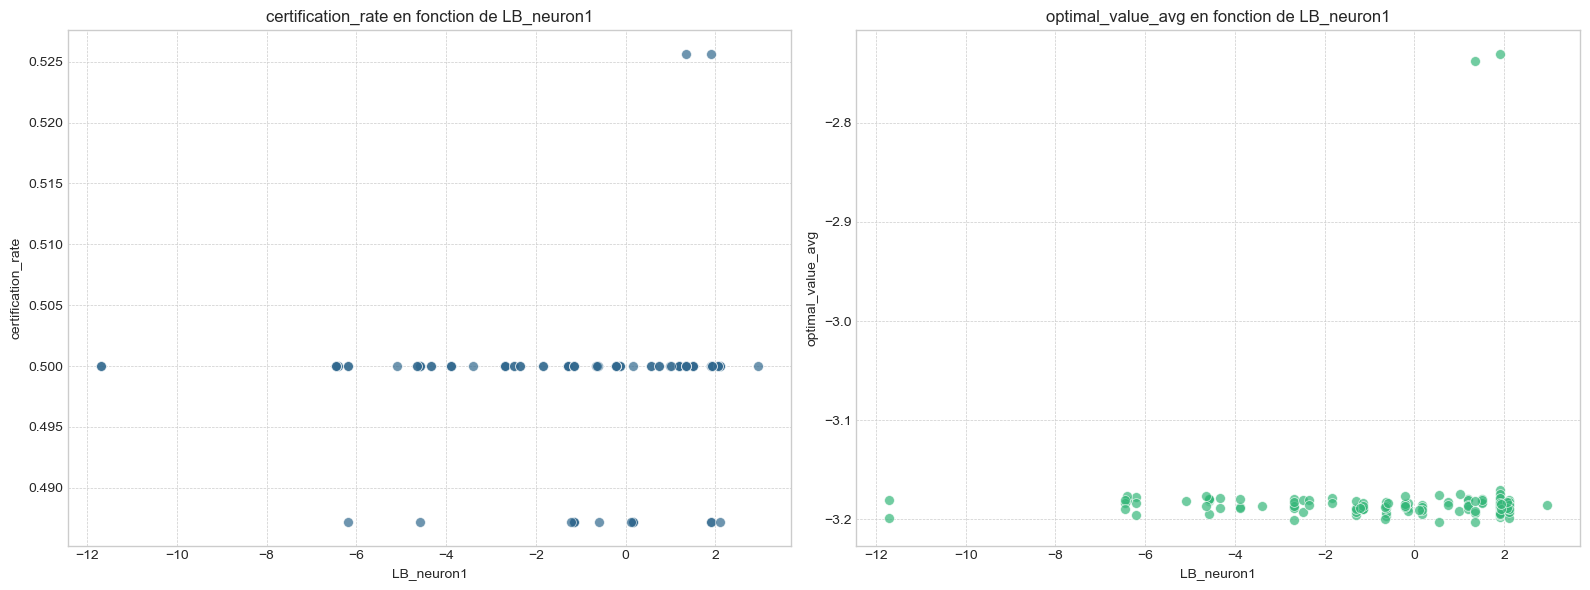

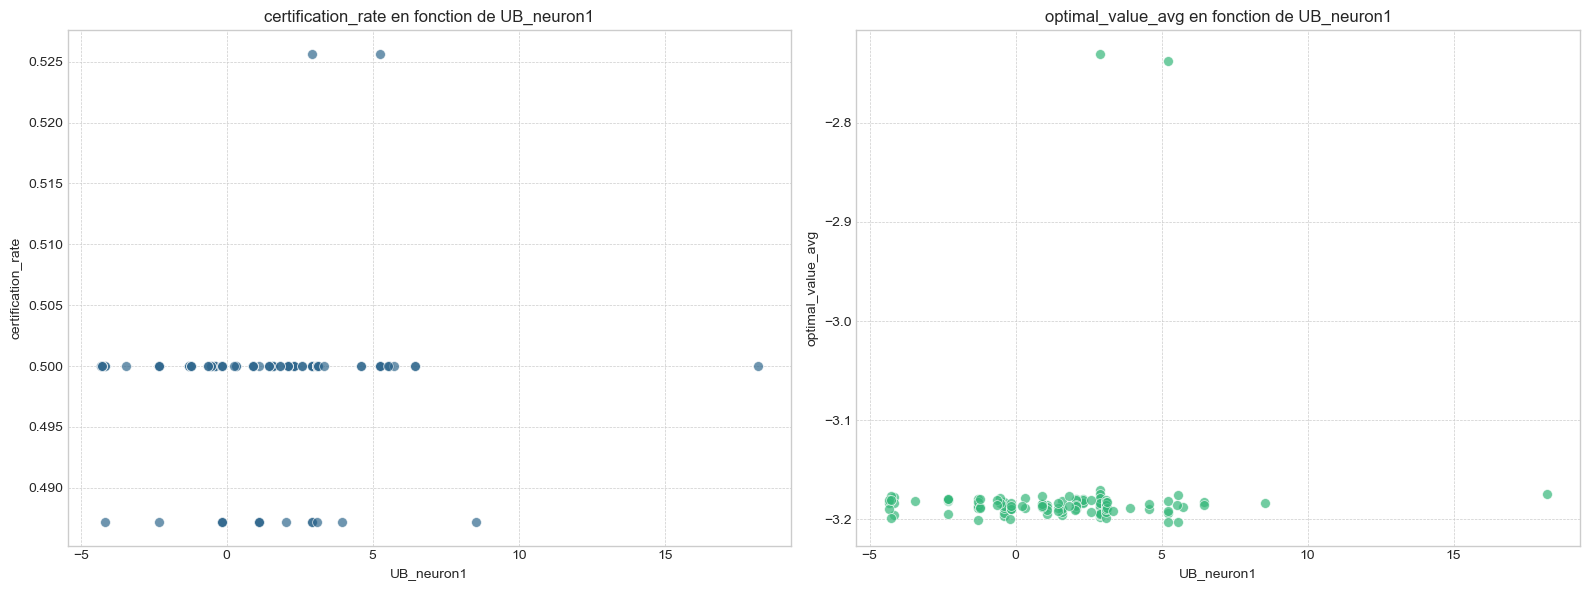

 --- Impact des bornes du neurone 2 ---


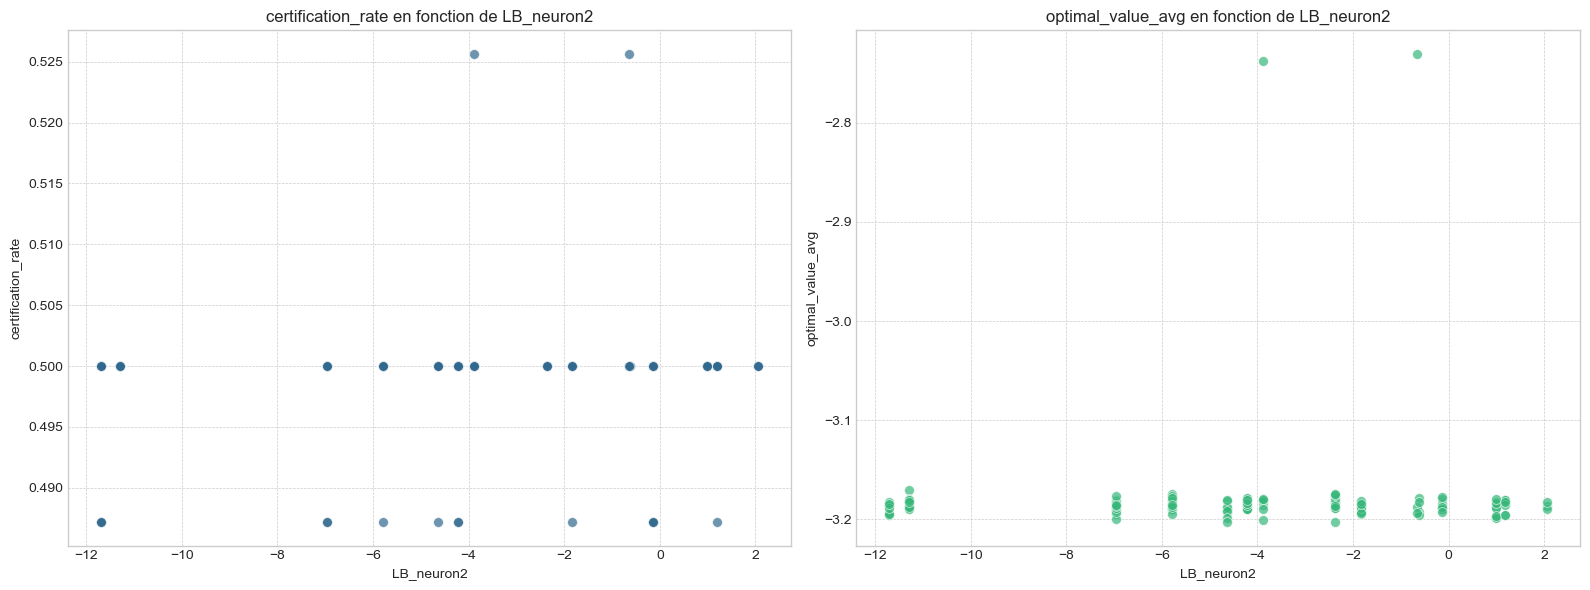

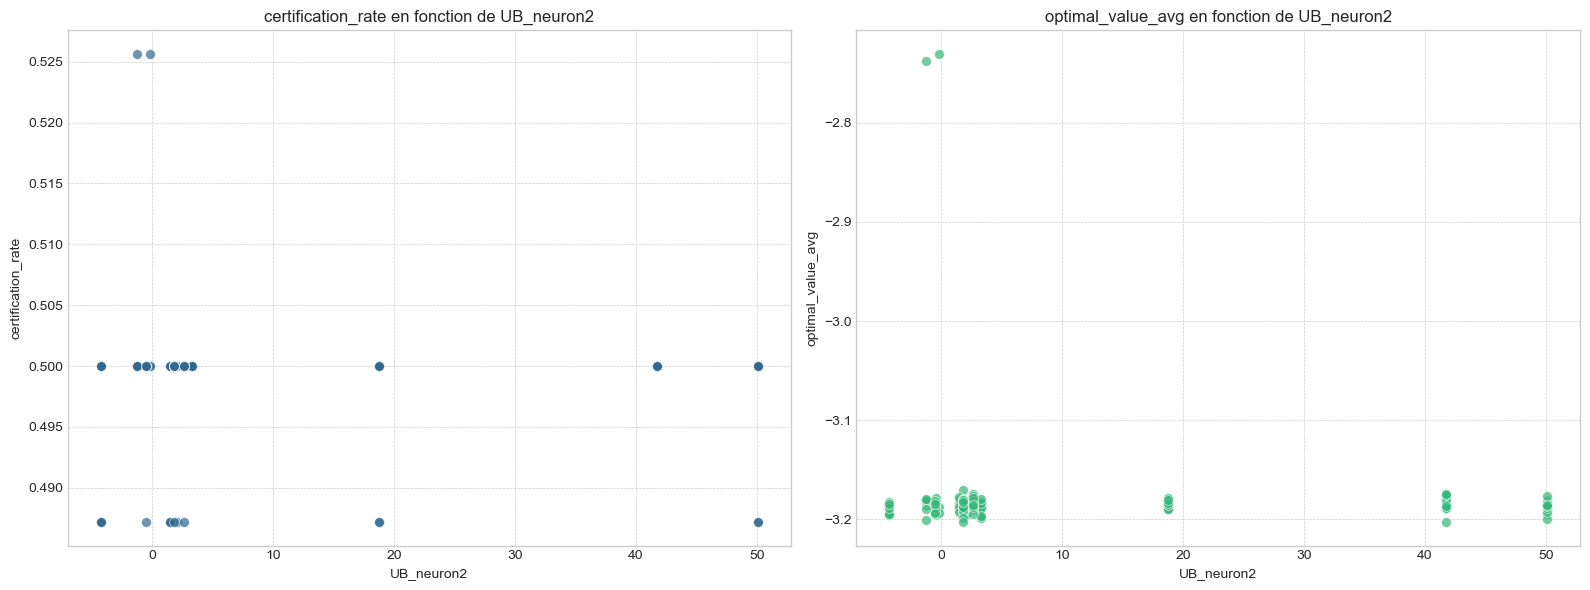

 --- Impact des indices de couche l et k ---


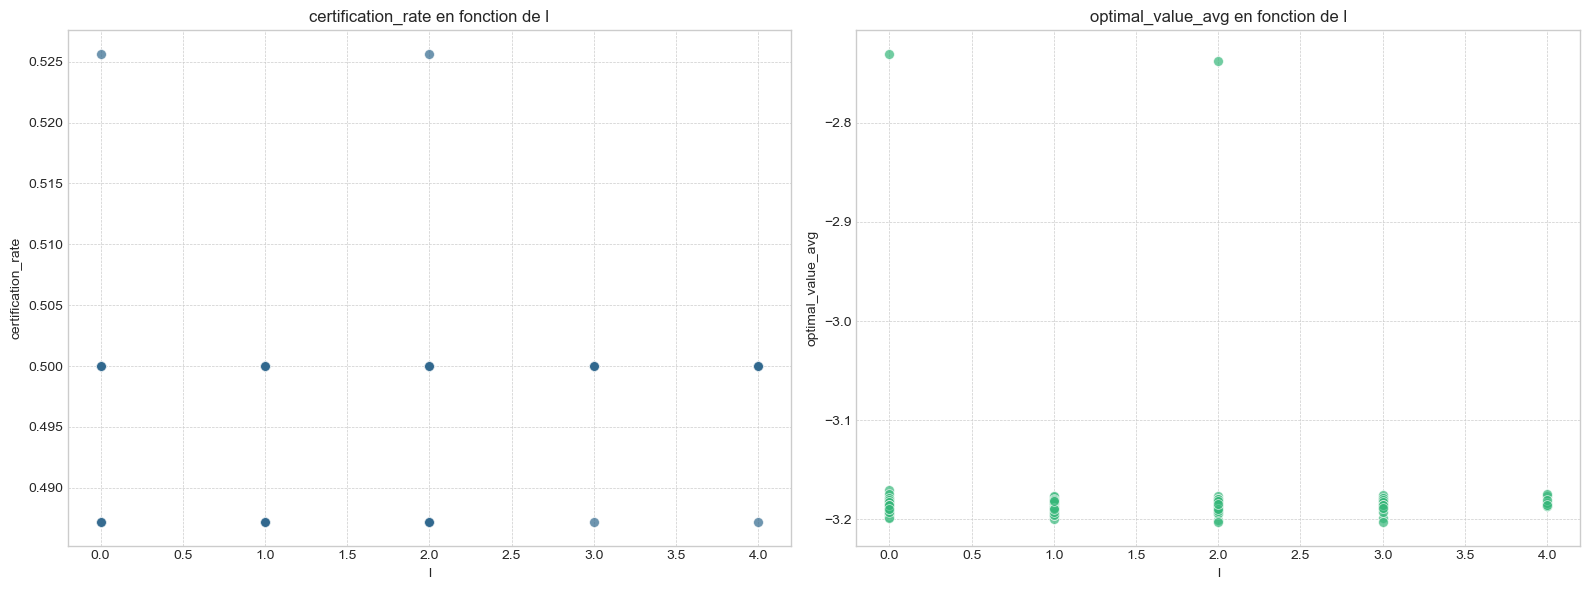

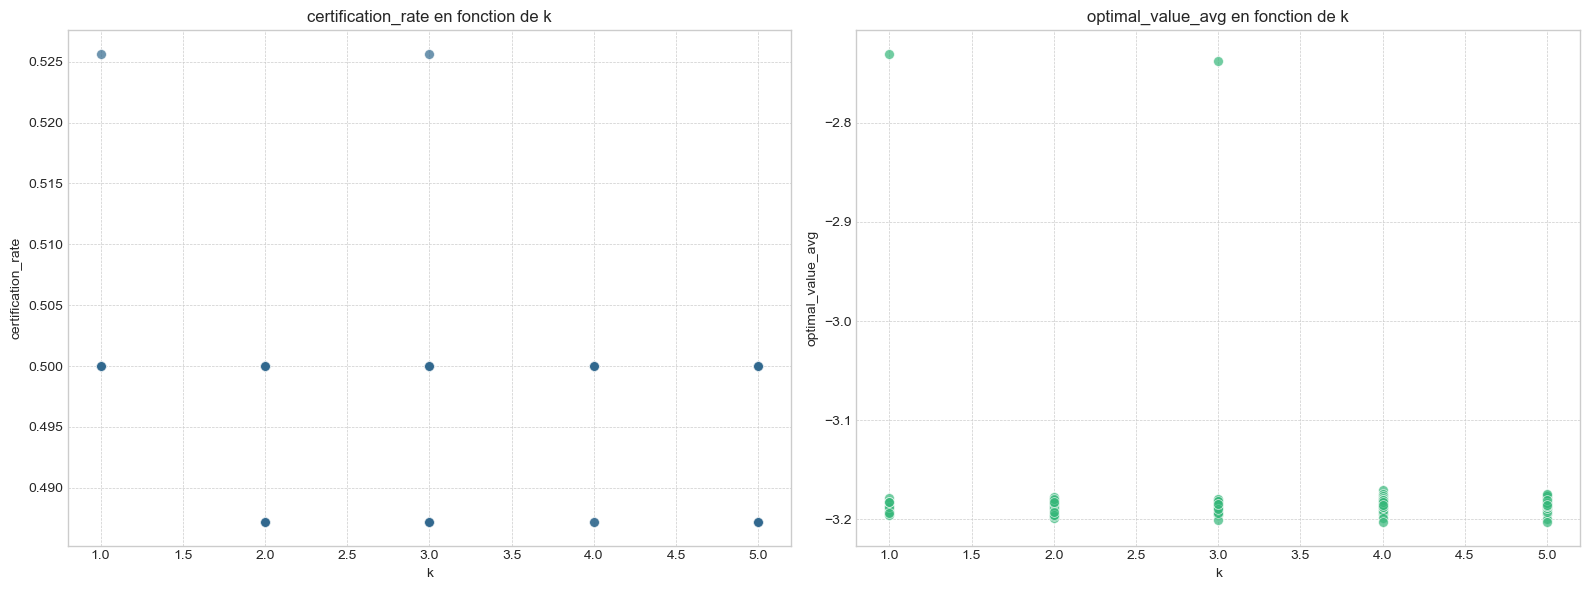

In [76]:
def plot_scatter(df, abscissa, criteria, figsize_per_plot=(8, 6), **kwargs):
    """ 
    Crée des nuages de points (scatter plots) pour chaque `criterion` en fonction de `abscissa`. 
    """ 
    if not criteria:
        print("Aucun critère à plotter.")
        return
 
    # On ne garde que les lignes où l'abscisse et les critères sont valides 
    plot_df = df[[abscissa] + criteria].dropna().copy()
    if plot_df.empty:
        print(f"Pas de données valides pour plotter '{abscissa}'.")
        return
 
    n_criteria = len(criteria)
    fig, axes = plt.subplots(1, n_criteria, figsize=(figsize_per_plot[0] * n_criteria, figsize_per_plot[1]), squeeze=False)
    axes = axes.flatten()
 
    colors = sns.color_palette("viridis", n_colors=n_criteria)
 
    for i, criterion in enumerate(criteria):
        ax = axes[i]
        # Utilisation de seaborn pour un plus joli rendu, avec la possibilité d'ajouter des kwargs
        sns.scatterplot(data=plot_df, x=abscissa, y=criterion, ax=ax, color=colors[i], **kwargs)
        ax.set_xlabel(abscissa)
        ax.set_ylabel(criterion)
        ax.set_title(f"{criterion} en fonction de {abscissa}")
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
 
    plt.tight_layout()
    plt.show()
 
# --- Exemples de plots --- 
# On se concentre sur les combos qui ne sont pas la baseline (où les bornes sont NaN) 
analysis_df = summary_df[summary_df['strategy'] != 'none'].copy()
 
if not analysis_df.empty:
    # Plot 1: Impact des bornes inférieures du premier neurone 
    # Plot 1: Impact des bornes du premier neurone
    print("--- Impact des bornes du neurone 1 ---")
    plot_scatter(analysis_df, \
                 abscissa='LB_neuron1', \
                 criteria=['certification_rate', 'optimal_value_avg'],\
                 alpha=0.7, s=50) # alpha pour la transparence, s pour la taille des points
    plot_scatter(analysis_df, \
                 abscissa='UB_neuron1', \
                 criteria=['certification_rate', 'optimal_value_avg'],\
                 alpha=0.7, s=50)
    
    # Plot 2: Impact des bornes supérieures du second neurone 
    # Plot 2: Impact des bornes du second neurone
    print(" --- Impact des bornes du neurone 2 ---")
    plot_scatter(analysis_df, \
                 abscissa='LB_neuron2', \
                 criteria=['certification_rate', 'optimal_value_avg'],\
                 alpha=0.7, s=50)
    plot_scatter(analysis_df, \
                 abscissa='UB_neuron2', \
                 criteria=['certification_rate', 'optimal_value_avg'],\
                 alpha=0.7, s=50)
    
    # Plot 3: Impact des indices de couche l et k
    print(" --- Impact des indices de couche l et k ---")
    plot_scatter(analysis_df, \
                 abscissa='l', \
                 criteria=['certification_rate', 'optimal_value_avg'],\
                 alpha=0.7, s=50)
    plot_scatter(analysis_df, \
                 abscissa='k', \
                 criteria=['certification_rate', 'optimal_value_avg'],\
                 alpha=0.7, s=50)
else:
    print("Le DataFrame 'summary_df' ne contient pas de données analysables pour les plots (ex: baseline uniquement).")

## Export (CSV + LaTeX pour le rapport)

In [77]:
OUTPUT_CSV = "combo_summary.csv"
summary_df.to_csv(OUTPUT_CSV, index=False)
print(f"Tableau exporté vers {OUTPUT_CSV}")

latex_table = display_df.to_latex(index=False, escape=True)
print(latex_table)


Tableau exporté vers combo_summary.csv
\begin{tabular}{llrrrrrlrrrrr}
\toprule
combo & strategy & l & u\_idx & k & j\_idx & n\_runs & certification\_rate & optimal\_value\_avg & LB\_neuron1 & UB\_neuron1 & LB\_neuron2 & UB\_neuron2 \\
\midrule
combo\_0000 & none & NaN & NaN & NaN & NaN & 78 & 52.6 \% & -2.731200 & NaN & NaN & NaN & NaN \\
combo\_0000 & none & NaN & NaN & NaN & NaN & 78 & 50.0 \% & -3.183800 & NaN & NaN & NaN & NaN \\
combo\_0000 & none & NaN & NaN & NaN & NaN & 78 & 50.0 \% & -3.177900 & NaN & NaN & NaN & NaN \\
combo\_0001 & composed & 0.000000 & 0.000000 & 1.000000 & 0.000000 & 78 & 50.0 \% & -3.186800 & 1.908200 & 2.908200 & 2.060900 & 3.128500 \\
combo\_0001 & composed & 0.000000 & 0.000000 & 1.000000 & 0.000000 & 78 & 50.0 \% & -3.189000 & 1.908200 & 2.908200 & 2.060900 & 3.128500 \\
combo\_0002 & composed & 0.000000 & 0.000000 & 1.000000 & 1.000000 & 78 & 50.0 \% & -3.178400 & 1.908200 & 2.908200 & -0.626200 & -0.385400 \\
combo\_0002 & composed & 0.000000 & 0.00